In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pyranges as pr

In [ ]:
txn = pd.read_csv('analysis_data/centroid_spermatids.csv', index_col=0)

,Early.RS,Int.RS,Late.RS,Early.ES
0610005C13Rik,0.000163,0.000803,0.000919,0.002878
0610007P14Rik,0.005748,0.007475,0.009413,0.023411
0610009B22Rik,0.967361,0.659551,0.384182,0.299016
0610009E02Rik,0.071724,0.026468,0.012501,0.005259
0610009L18Rik,2.914551,2.175103,1.716665,2.054357


In [67]:
df = pd.read_csv('analysis_data/merged_gc_resids_with_compartment_scores.csv', index_col=0)[['chrom', 'start', 'end', 'early_RS', 'int_RS', 'late_RS', 'early_ES']]
df.head()

/tmp/ipykernel_2548130/1613763009.py:1: DtypeWarning: Columns (12,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('analysis_data/merged_gc_resids_with_compartment_scores.csv', index_col=0)[['chrom', 'start', 'end', 'early_RS', 'int_RS', 'late_RS', 'early_ES']]


,chrom,start,end,early_RS,int_RS,late_RS,early_ES
0,chr1,0,1000,1.765159,0.026496,2.806114,2.328808
1,chr1,1000,2000,1.765159,0.026496,2.806114,2.328808
2,chr1,2000,3000,1.765159,0.026496,2.806114,2.328808
3,chr1,3000,4000,1.765159,0.026496,2.806114,2.328808
4,chr1,4000,5000,1.765159,0.026496,2.806114,2.328808


In [68]:
gr = pr.read_gtf("references/Mus_musculus.GRCm38.81.gtf.gz")
genes = gr[gr.Feature == "gene"]
df_genes = genes.as_df()
df_genes.head()

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_version,...,havana_transcript,havana_transcript_version,tag,transcript_support_level,exon_number,exon_id,exon_version,ccds_id,protein_id,protein_version
0,1,havana,gene,3073252,3074322,.,+,.,ENSMUSG00000102693,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,ensembl,gene,3102015,3102125,.,+,.,ENSMUSG00000064842,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,havana,gene,3252756,3253236,.,+,.,ENSMUSG00000102851,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,havana,gene,3466586,3513553,.,+,.,ENSMUSG00000089699,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,havana,gene,3531794,3532720,.,+,.,ENSMUSG00000103147,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [69]:
# replace chromosome numbers with 'chr' prefix
df_genes['Chromosome'] = 'chr' + df_genes['Chromosome'].astype(str)

In [70]:
# find genes that have multiple sources
multisource_genes = df_genes.groupby('gene_name').filter(lambda x: len(x['Source'].unique()) > 1)['gene_name'].unique()

In [71]:
# ensembl_havana is preferered source
# keep these rows and drop non ensembl_havana rows for these genes
eh_genes = df_genes[df_genes.gene_name.isin(multisource_genes) & (df_genes.Source=='ensembl_havana')].gene_name.unique()

# if a gene is in eh_genes, keep only ensembl_havana rows
df_genes_filtered = df_genes[~((df_genes.gene_name.isin(eh_genes)) & (df_genes.Source != 'ensembl_havana'))]


In [72]:
hav_genes = df_genes_filtered.groupby('gene_name').filter(lambda x: len(x['Source'].unique()) > 1)['gene_name'].unique()

In [73]:
# havana is more reliable than ensembl
# keep these rows and drop non havana rows for these genes
df_genes_filtered = df_genes_filtered[~((df_genes_filtered.gene_name.isin(hav_genes)) & (df_genes_filtered.Source != 'havana'))]


In [81]:
# no more dupes
df_genes_filtered.groupby('gene_name').filter(lambda x: len(x['Source'].unique()) > 1)

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_version,...,havana_transcript,havana_transcript_version,tag,transcript_support_level,exon_number,exon_id,exon_version,ccds_id,protein_id,protein_version


there are still duplicate genes

In [74]:
# keep older version when there are multiple gene_ids for the same gene_name in the same source
df_genes_filtered = df_genes_filtered.sort_values(['gene_name', 'gene_version']).drop_duplicates(subset=['gene_name', 'Source'], keep='first')

they match.

### Join txn

In [75]:
txn_genes = txn.reset_index().rename(columns={'index': 'gene_name'}).merge(df_genes_filtered[['gene_name', 'Chromosome', 'Start', 'End']], on='gene_name')


In [96]:
len(txn), len(txn_genes)

(24931, 24929)

In [13]:
txn_genes.gene_name.nunique()

24929

there are some gene names mapped to multiple locations in gtf file, and some genes not mapped at all. check the left join

In [97]:
txn_genes.head()

,gene_name,Early.RS,Int.RS,Late.RS,Early.ES,Chromosome,Start,End
0,0610005C13Rik,0.000163,0.000803,0.000919,0.002878,chr7,45567794,45575327
1,0610007P14Rik,0.005748,0.007475,0.009413,0.023411,chr12,85815447,85824550
2,0610009B22Rik,0.967361,0.659551,0.384182,0.299016,chr11,51685385,51688874
3,0610009E02Rik,0.071724,0.026468,0.012501,0.005259,chr2,26445695,26459390
4,0610009L18Rik,2.914551,2.175103,1.716665,2.054357,chr11,120348677,120351190


In [98]:
# start always less than end
txn_genes[txn_genes.Start > txn_genes.End]

,gene_name,Early.RS,Int.RS,Late.RS,Early.ES,Chromosome,Start,End


In [ ]:
# Prepare bins DataFrame
bins = df.copy()
bins.rename(columns={'chrom': 'Chromosome', 'start': 'Start', 'end': 'End'}, inplace=True)

# Sort bins and txn_genes for merge_asof
bins_sorted = bins.sort_values(['End'])
txn_genes_sorted = txn_genes.sort_values(['Start'])

# Find the preceding bin for each gene using merge_asof (much less memory)
preceding_bins = pd.merge_asof(
    txn_genes_sorted,
    bins_sorted,
    left_on='Start',
    right_on='End',
    by='Chromosome',
    direction='backward'
)
preceding_bins.rename(columns={'Start_y': 'Start', 'End_y': 'End'}, inplace=True)
preceding_bins = preceding_bins[['Chromosome', 'Start', 'End', 'early_RS', 'int_RS', 'late_RS', 'early_ES', 'gene_name']]
# Remove genes where no preceding bin was found (if any)
preceding_bins = preceding_bins.dropna(subset=['Start', 'End'])

preceding_bins.rename(columns={
    'early_RS': 'ATAC_early_RS',
    'int_RS': 'ATAC_int_RS',
    'late_RS': 'ATAC_late_RS',
    'early_ES': 'ATAC_early_ES'
}, inplace=True)


In [77]:
# Prepare pyranges objects
pr_df = pr.PyRanges(df.rename(columns={'chrom': 'Chromosome', 'start': 'Start', 'end': 'End',
                                        'early_RS': 'ATAC_early_RS', 'int_RS': 'ATAC_int_RS', 'late_RS': 'ATAC_late_RS', 'early_ES': 'ATAC_early_ES'}))
pr_genes = pr.PyRanges(txn_genes.rename(columns={'Chromosome': 'Chromosome', 'Start': 'Start', 'End': 'End',
                                                'Early.RS': 'txn_early_RS', 'Int.RS': 'txn_int_RS', 'Late.RS': 'txn_late_RS', 'Early.ES': 'txn_early_ES'}))

# Perform overlap join
joined = pr_df.join(pr_genes, suffix='_gene')

# Convert to DataFrame
joined_df = joined.as_df()

# Group by gene_name and take mean ATAC score (replace 'early_RS' with your ATAC column)
#mean_atac_by_gene = joined_df.groupby('gene_name')['early_RS'].mean().reset_index()

In [78]:
# join preceding bins ATAC scores to genes
prec_joined_df = preceding_bins.merge(pr_genes.as_df(), on='gene_name', suffixes=('', '_gene')).drop(columns=['Chromosome_gene'])

In [79]:
prec_joined_df.head()

,Chromosome,Start,End,ATAC_early_RS,ATAC_int_RS,ATAC_late_RS,ATAC_early_ES,gene_name,txn_early_RS,txn_int_RS,txn_late_RS,txn_early_ES,Start_gene,End_gene
0,chrY,724000.0,725000.0,0.760117,0.468374,1.325739,0.297750,Zfy1,0.133804,0.125304,0.144675,0.026550,725127,797409
1,chrY,817000.0,818000.0,0.101946,-0.151737,0.236892,-0.396984,Uba1y,0.013806,0.008370,0.009984,0.000129,818648,844224
2,chrY,896000.0,897000.0,-0.467582,-1.882124,-0.674757,-2.241160,Kdm5d,0.006390,0.005442,0.003246,0.001806,897787,956786
3,chrY,1009000.0,1010000.0,2.595270,4.269904,2.911706,-2.812437,Eif2s3y,1.083442,1.241990,0.459397,0.040260,1010542,1028847
4,chrY,1047000.0,1048000.0,-0.519246,-0.624754,-0.601012,-1.319175,Gm29650,0.000077,0.000374,0.000316,0.000479,1048392,1049134


In [53]:
# working
prec_joined_df.gene_name.nunique(), len(prec_joined_df)

(24845, 24845)

In [36]:
joined_df.head()

,Chromosome,Start,End,ATAC_early_RS,ATAC_int_RS,ATAC_late_RS,ATAC_early_ES,gene_name,txn_early_RS,txn_int_RS,txn_late_RS,txn_early_ES,Start_gene,End_gene
0,chr1,3073000,3074000,-2.576662,-3.088719,-1.297268,-3.437919,4933401J01Rik,0.013620,0.012846,0.002771,0.000318,3073252,3074322
1,chr1,3074000,3075000,-1.108752,-1.810708,-0.112746,-0.050237,4933401J01Rik,0.013620,0.012846,0.002771,0.000318,3073252,3074322
2,chr1,4290000,4291000,-1.720215,1.030752,0.019340,0.600124,Rp1,0.054723,0.036238,0.022254,0.011789,4290845,4409241
3,chr1,4291000,4292000,-0.051642,-0.483601,2.114279,-1.209591,Rp1,0.054723,0.036238,0.022254,0.011789,4290845,4409241
4,chr1,4292000,4293000,0.002493,0.713892,0.047652,-1.014877,Rp1,0.054723,0.036238,0.022254,0.011789,4290845,4409241


In [80]:
joined_with_preceding = pd.concat([joined_df, prec_joined_df], ignore_index=True).drop_duplicates()

In [61]:
joined_with_preceding.head()

,Chromosome,Start,End,ATAC_early_RS,ATAC_int_RS,ATAC_late_RS,ATAC_early_ES,gene_name,txn_early_RS,txn_int_RS,txn_late_RS,txn_early_ES,Start_gene,End_gene
0,chr1,3073000.0,3074000.0,-2.576662,-3.088719,-1.297268,-3.437919,4933401J01Rik,0.013620,0.012846,0.002771,0.000318,3073252,3074322
1,chr1,3074000.0,3075000.0,-1.108752,-1.810708,-0.112746,-0.050237,4933401J01Rik,0.013620,0.012846,0.002771,0.000318,3073252,3074322
2,chr1,4290000.0,4291000.0,-1.720215,1.030752,0.019340,0.600124,Rp1,0.054723,0.036238,0.022254,0.011789,4290845,4409241
3,chr1,4291000.0,4292000.0,-0.051642,-0.483601,2.114279,-1.209591,Rp1,0.054723,0.036238,0.022254,0.011789,4290845,4409241
4,chr1,4292000.0,4293000.0,0.002493,0.713892,0.047652,-1.014877,Rp1,0.054723,0.036238,0.022254,0.011789,4290845,4409241


In [46]:
len(joined_with_preceding)

1082804

In [81]:
ERS = joined_with_preceding[['Chromosome', 'Start', 'End','gene_name', 'txn_early_RS', 'ATAC_early_RS']]
IRS = joined_with_preceding[['Chromosome', 'Start', 'End','gene_name', 'txn_int_RS', 'ATAC_int_RS']]
LRS = joined_with_preceding[['Chromosome', 'Start', 'End','gene_name', 'txn_late_RS', 'ATAC_late_RS']]
EES = joined_with_preceding[['Chromosome', 'Start', 'End','gene_name', 'txn_early_ES', 'ATAC_early_ES']]

In [ ]:
# average txn scores by gene
ERS_ATAC_mean_by_gene = ERS.groupby('gene_name')['ATAC_early_RS'].mean().reset_index()
IRS_ATAC_mean_by_gene = IRS.groupby('gene_name')['ATAC_int_RS'].mean().reset_index()
LRS_ATAC_mean_by_gene = LRS.groupby('gene_name')['ATAC_late_RS'].mean().reset_index()
EES_ATAC_mean_by_gene = EES.groupby('gene_name')['ATAC_early_ES'].mean().reset_index()

In [ ]:
def get_tss_atac_scores(joined_df, stage, window=1000):
    """
    Returns a DataFrame with mean ATAC scores around the TSS for each gene for a given stage.
    Only bins within +/- window bp of the TSS are considered.
    """
    atac_col = f'ATAC_{stage}'
    tss_atac_scores = []
    for gene_name, group in joined_df.groupby('gene_name'):
        tss = group['Start_gene'].min()
            # Find bins overlapping TSS
        tss_region = group[(group['Start'] <= tss) & (group['End'] >= tss)]
        if not tss_region.empty:
            tss_start = tss_region.Start.iloc[0]
            tss_end = tss_region.End.iloc[0]
                # Filter bins within window around TSS
            surrounding = group[
                    (group['Start'] >= tss_start - window) &
                    (group['End'] <= tss_end + window)
                ]
            mean_atac = surrounding[atac_col].mean()
            tss_atac_scores.append({'gene_name': gene_name, f'mean_ATAC_{stage}': mean_atac})
    return pd.DataFrame(tss_atac_scores)

In [ ]:
ERS_TSS_ATAC_mean = get_tss_atac_scores(joined_with_preceding, 'early_RS')


,gene_name,mean_ATAC_early_RS
0,0610005C13Rik,1.062236
1,0610007P14Rik,3.007391
2,0610009B22Rik,-0.000007
3,0610009E02Rik,-0.170342
4,0610009L18Rik,2.273307
5,0610009O20Rik,-0.179830
6,0610010F05Rik,-0.023876
7,0610010K14Rik,-0.423705
8,0610011F06Rik,-1.392859
9,0610025J13Rik,2.177885


In [110]:
IRS_TSS_ATAC_mean = get_tss_atac_scores(joined_with_preceding, 'int_RS')
LRS_TSS_ATAC_mean = get_tss_atac_scores(joined_with_preceding, 'late_RS')
EES_TSS_ATAC_mean = get_tss_atac_scores(joined_with_preceding, 'early_ES')

In [111]:
from functools import reduce
txn_genes = txn_genes.rename(columns={'Early.RS': 'txn_early_RS', 'Int.RS': 'txn_int_RS', 'Late.RS': 'txn_late_RS', 'Early.ES': 'txn_early_ES'})

#dfs = [txn_genes, ERS_ATAC_mean_by_gene, IRS_ATAC_mean_by_gene, LRS_ATAC_mean_by_gene, EES_ATAC_mean_by_gene]
dfs = [txn_genes, ERS_TSS_ATAC_mean, IRS_TSS_ATAC_mean, LRS_TSS_ATAC_mean, EES_TSS_ATAC_mean]
merged = reduce(lambda left, right: pd.merge(left, right, on='gene_name'), dfs)

In [112]:
merged.head()

,gene_name,txn_early_RS,txn_int_RS,txn_late_RS,txn_early_ES,Chromosome,Start,End,mean_ATAC_early_RS,mean_ATAC_int_RS,mean_ATAC_late_RS,mean_ATAC_early_ES
0,0610005C13Rik,0.000163,0.000803,0.000919,0.002878,chr7,45567794,45575327,1.062236,1.222509,0.581329,0.517143
1,0610007P14Rik,0.005748,0.007475,0.009413,0.023411,chr12,85815447,85824550,3.007391,6.260687,3.075231,0.178746
2,0610009B22Rik,0.967361,0.659551,0.384182,0.299016,chr11,51685385,51688874,-0.000007,-0.448228,-0.117504,0.340263
3,0610009E02Rik,0.071724,0.026468,0.012501,0.005259,chr2,26445695,26459390,-0.170342,-0.479114,0.643629,1.547240
4,0610009L18Rik,2.914551,2.175103,1.716665,2.054357,chr11,120348677,120351190,2.273307,1.907810,0.921162,-0.765838


<Axes: xlabel='txn', ylabel='mean_ATAC'>

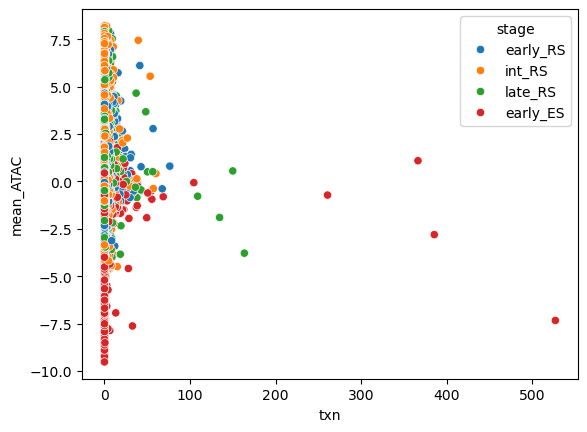

In [115]:
merged_long = pd.melt(
    merged.drop(columns=['Chromosome', 'Start', 'End']),
    id_vars=['gene_name'],
    value_vars=['txn_early_RS', 'txn_int_RS', 'txn_late_RS', 'txn_early_ES', 'mean_ATAC_early_RS', 'mean_ATAC_int_RS', 'mean_ATAC_late_RS', 'mean_ATAC_early_ES']
)

# Split variable into type and stage
merged_long[['type', 'stage']] = merged_long['variable'].str.extract(r'(txn|mean_ATAC)_(.*)')
merged_long = merged_long.drop(columns=['variable'])
merged_long.head()
# Pivot so each row has txn and ATAC for each gene/stage
plot_df = merged_long.pivot_table(index=['gene_name', 'stage'], columns='type', values='value').reset_index()

# Plot
sns.scatterplot(data=plot_df, x='txn', y='mean_ATAC', hue='stage', hue_order=['early_RS', 'int_RS', 'late_RS', 'early_ES']
)

(-5.0, 5.0)

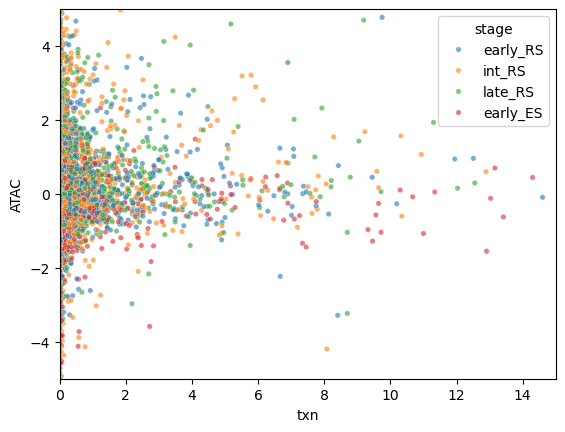

In [17]:
sampled_df = plot_df.sample(n=10000, random_state=1) 

sns.scatterplot(data=sampled_df, x='txn', y='ATAC',
                hue='stage',
                hue_order=['early_RS', 'int_RS', 'late_RS', 'early_ES'],
                alpha=0.6,
                s=15)
plt.xlim(0,15)
plt.ylim(-5,5)


(-5.0, 5.0)

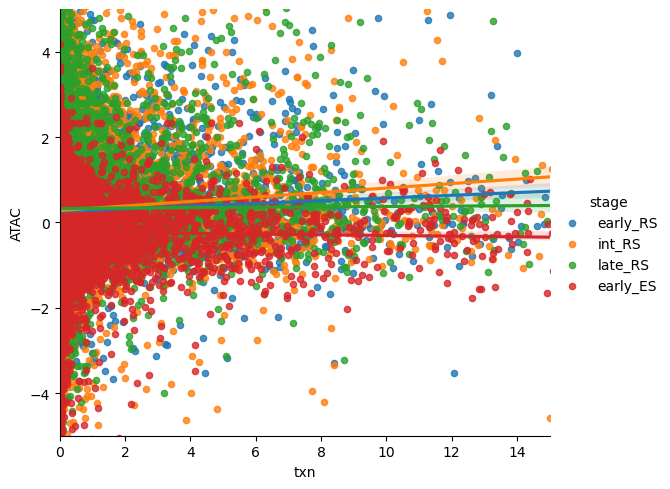

In [22]:
sns.lmplot(
    data=plot_df,
    x='txn',
    y='ATAC',
    hue='stage',
    hue_order=['early_RS', 'int_RS', 'late_RS', 'early_ES'],
    scatter_kws={'s': 20},
    aspect=1.2,
    height=5,
    fit_reg=True
)
plt.xlim(0,15)
plt.ylim(-5,5)

/tmp/ipykernel_2548130/1437148564.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(20, 'txn'))


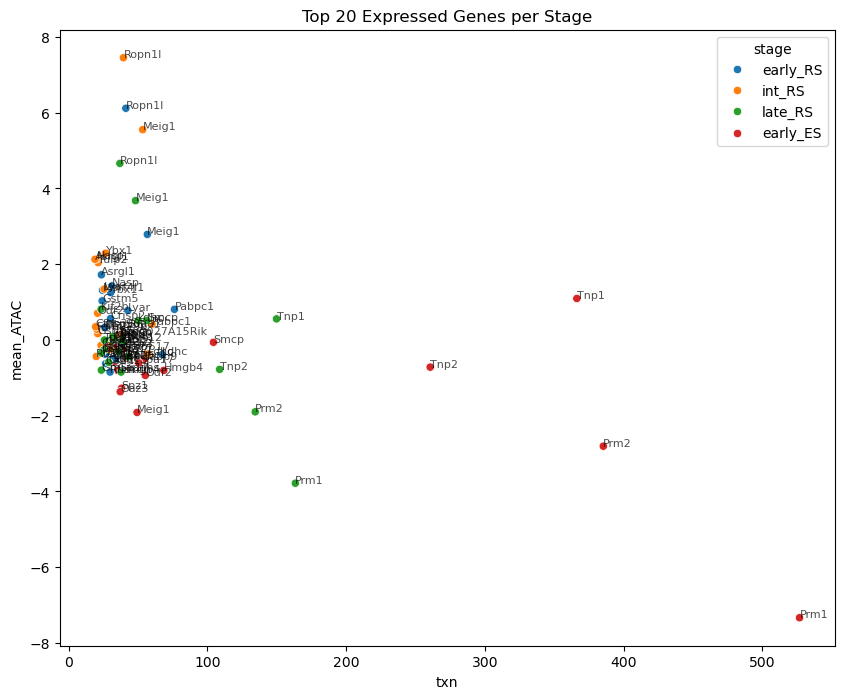

In [116]:
# Find top 20 expressed genes for each stage
top_genes_per_stage = (
    plot_df.groupby('stage')
    .apply(lambda x: x.nlargest(20, 'txn'))
    .reset_index(drop=True)
)
# Plot for top 20 expressed genes per stage, annotated with gene_name
plt.figure(figsize=(10, 8))
ax = sns.scatterplot(
    data=top_genes_per_stage,
    x='txn',
    y='mean_ATAC',
    hue='stage',
    hue_order=['early_RS', 'int_RS', 'late_RS', 'early_ES']
)
plt.title("Top 20 Expressed Genes per Stage")


# Annotate each point with gene_name
for _, row in top_genes_per_stage.iterrows():
    ax.text(row['txn'], row['mean_ATAC'], row['gene_name'], fontsize=8, alpha=0.7)

plt.show()

In [ ]:
# used for regression analysis in R
plot_df.to_csv('/nfs/turbo/umms-minjilab/zapell/temp_dir_hammoud_lab/txn_atac_AT_TSS_regression_data_ref_GRCm38.81.csv', index=False)